# 1 Импорт библиотек

In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from ucimlrepo import fetch_ucirepo


# 2 Загрузка данных

In [41]:
dropout_data = fetch_ucirepo(id=697)
X = dropout_data.data.features
y = dropout_data.data.targets

feature_names = ['Marital Status', 'Application mode', 'Application order', 'Course', 'Daytime/evening attendance', 'Previous qualification', 'Previous qualification (grade)',
    'Nacionality', "Mother's qualification", "Father's qualification", "Mother's occupation", "Father's occupation", 'Admission grade', 'Displaced', 'Educational special needs', 'Debtor', 'Tuition fees up to date', 'Gender', 'Scholarship holder', 'Age at enrollment', 'International', 'Curricular units 1st sem (credited)', 'Curricular units 1st sem (enrolled)',
    'Curricular units 1st sem (evaluations)', 'Curricular units 1st sem (approved)', 'Curricular units 1st sem (grade)', 'Curricular units 1st sem (without evaluations)',
    'Curricular units 2nd sem (credited)', 'Curricular units 2nd sem (enrolled)', 'Curricular units 2nd sem (evaluations)', 'Curricular units 2nd sem (approved)',
    'Curricular units 2nd sem (grade)', 'Curricular units 2nd sem (without evaluations)', 'Unemployment rate', 'Inflation rate', 'GDP']
df = pd.DataFrame(X, columns=feature_names)
df['Target'] = y.values.flatten()

# 3 Предобработка

In [42]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(df['Target'])

categorical_features = ['Marital Status', 'Application mode', 'Course', 'Daytime/evening attendance', 'Previous qualification', 'Nacionality', "Mother's qualification",
    "Father's qualification", "Mother's occupation", "Father's occupation", 'Displaced', 'Educational special needs', 'Debtor', 'Tuition fees up to date',
    'Gender', 'Scholarship holder', 'International']
X_processed = pd.get_dummies(df.drop('Target', axis=1), columns=categorical_features, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(X_processed, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4 Softmax + градиентный спуск

In [43]:
class LogisticRegressionScratch:
    def __init__(self, learning_rate=0.01, n_iters=8000):
        self.lr = learning_rate
        self.n_iters = n_iters
        self.weights = None
        self.bias = None
        self.loss_history = []

    def _softmax(self, z):
        exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
        return exp_z / np.sum(exp_z, axis=1, keepdims=True)

    def _one_hot(self, y, n_classes):
        one_hot = np.zeros((y.shape[0], n_classes))
        one_hot[np.arange(y.shape[0]), y] = 1
        return one_hot

    def fit(self, X, y):
        n_samples, n_features = X.shape
        n_classes = len(np.unique(y))
        self.weights = np.random.randn(n_features, n_classes) * np.sqrt(2. / n_features)
        self.bias = np.zeros(n_classes)
        y_one_hot = self._one_hot(y, n_classes)

        for i in range(self.n_iters):
            linear = np.dot(X, self.weights) + self.bias
            y_pred = self._softmax(linear)
            loss = -np.mean(np.sum(y_one_hot * np.log(y_pred + 1e-9), axis=1))
            self.loss_history.append(loss)

            error = y_pred - y_one_hot
            self.weights -= self.lr * (1 / n_samples) * np.dot(X.T, error)
            self.bias -= self.lr * (1 / n_samples) * np.sum(error, axis=0)

    def predict_proba(self, X):
        linear = np.dot(X, self.weights) + self.bias
        return self._softmax(linear)

    def predict(self, X):
        proba = self.predict_proba(X)
        return np.argmax(proba, axis=1)

# 5 Обучение

In [44]:
model = LogisticRegressionScratch(learning_rate=0.001, n_iters=80000)
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

# 6 Оценка

In [45]:
print(f"Точность: {accuracy_score(y_test, y_pred):.4f}")
print(classification_report(y_test, y_pred, target_names=['Dropout', 'Enrolled', 'Graduate']))

Точность: 0.7435
              precision    recall  f1-score   support

     Dropout       0.78      0.73      0.75       284
    Enrolled       0.48      0.36      0.41       159
    Graduate       0.79      0.89      0.84       442

    accuracy                           0.74       885
   macro avg       0.68      0.66      0.67       885
weighted avg       0.73      0.74      0.73       885



# 7 Матрица ошибок

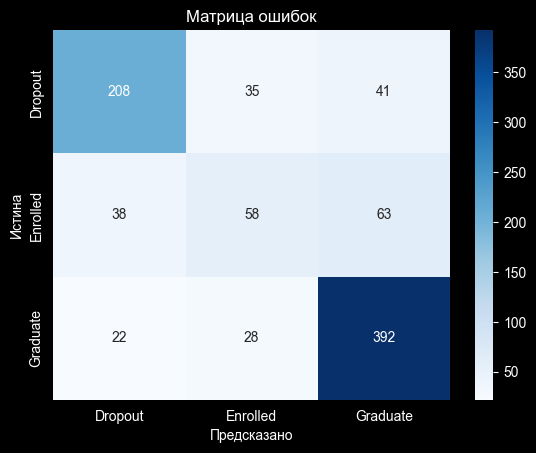

In [46]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Dropout', 'Enrolled', 'Graduate'],
            yticklabels=['Dropout', 'Enrolled', 'Graduate'])
plt.title('Матрица ошибок')
plt.xlabel('Предсказано')
plt.ylabel('Истина')
plt.show()

# 8 График обучения

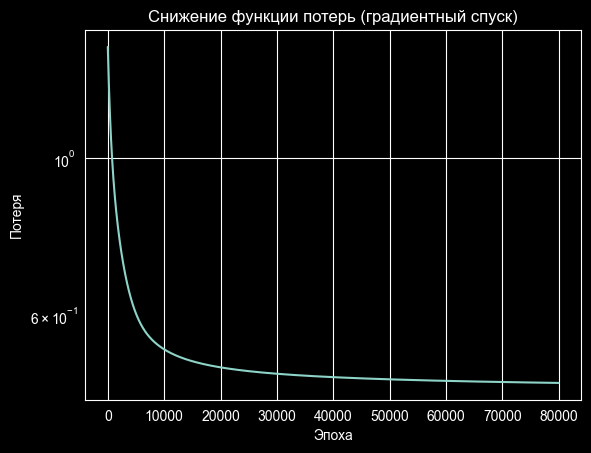

In [47]:
plt.plot(model.loss_history)
plt.title('Снижение функции потерь (градиентный спуск)')
plt.xlabel('Эпоха')
plt.ylabel('Потеря')
plt.yscale('log')
plt.show()

# 9 Предсказание для одного студента

In [48]:
sample_idx = 34
sample = X_test_scaled[sample_idx].reshape(1, -1)
true_label = y_test[sample_idx]
pred_label = model.predict(sample)[0]

proba = model.predict_proba(sample)[0] # Вероятности по классам

print("-"*66)
print("Предсказание для одного студента")
print("-"*66)
print(f"Истинный статус: {label_encoder.inverse_transform([true_label])[0]}")
print(f"Предсказанный статус: {label_encoder.inverse_transform([pred_label])[0]}")
print("\nВероятности:")
print(f"  Отчислен : {proba[0]:.4f}")
print(f"  Продолжает : {proba[1]:.4f}")
print(f"  Выпускник : {proba[2]:.4f}")

------------------------------------------------------------------
Предсказание для одного студента
------------------------------------------------------------------
Истинный статус: Dropout
Предсказанный статус: Dropout

Вероятности:
  Отчислен : 0.9713
  Продолжает : 0.0258
  Выпускник : 0.0029
